In [1]:
import os
import glob

import cv2
import numpy as np
import matplotlib.pyplot as plt

%matplotlib inline

BASE_DIR = os.path.abspath('..')  # if notebook resides in /notebooks
DATA_DIR = os.path.join(BASE_DIR, 'data')
REC_DIR = os.path.join(DATA_DIR, 'receipts_raw')

print("DATA_DIR:", DATA_DIR)
print("REC_DIR:", REC_DIR)

DATA_DIR: d:\HND NIBM\img processing & computer vision project\kyc-robustness\data
REC_DIR: d:\HND NIBM\img processing & computer vision project\kyc-robustness\data\receipts_raw


In [ ]:
def show_image(title, img, cmap=None, size=(6, 6)):
    plt.figure(figsize=size)
    if cmap is None:
        plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    else:
        plt.imshow(img, cmap=cmap)
    plt.title(title)
    plt.axis('off')
    plt.show()

In [4]:
rec_paths = glob.glob(os.path.join(REC_DIR, '*'))
print("Number of receipt images:", len(rec_paths))
rec_paths[:5]

Number of receipt images: 101


['d:\\HND NIBM\\img processing & computer vision project\\kyc-robustness\\data\\receipts_raw\\000.jpg',
 'd:\\HND NIBM\\img processing & computer vision project\\kyc-robustness\\data\\receipts_raw\\001.jpg',
 'd:\\HND NIBM\\img processing & computer vision project\\kyc-robustness\\data\\receipts_raw\\002.jpg',
 'd:\\HND NIBM\\img processing & computer vision project\\kyc-robustness\\data\\receipts_raw\\003.jpg',
 'd:\\HND NIBM\\img processing & computer vision project\\kyc-robustness\\data\\receipts_raw\\004.jpg']

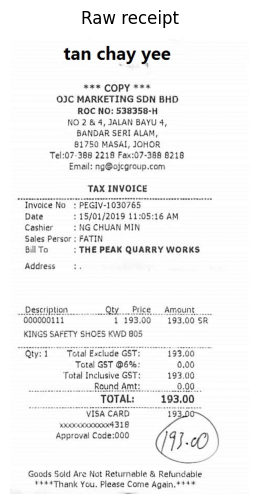

In [5]:
rec_img = cv2.imread(rec_paths[0])
show_image("Raw receipt", rec_img)

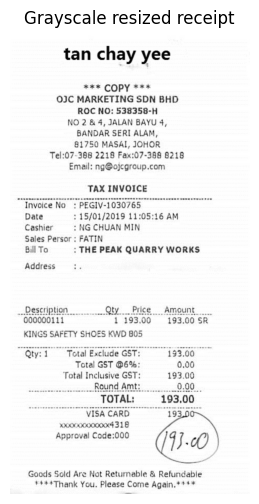

In [6]:
rec_gray = cv2.cvtColor(rec_img, cv2.COLOR_BGR2GRAY)

h, w = rec_gray.shape
new_w = 800
scale = new_w / w
new_h = int(h * scale)
rec_gray_resized = cv2.resize(rec_gray, (new_w, new_h))

show_image("Grayscale resized receipt", rec_gray_resized, cmap='gray')

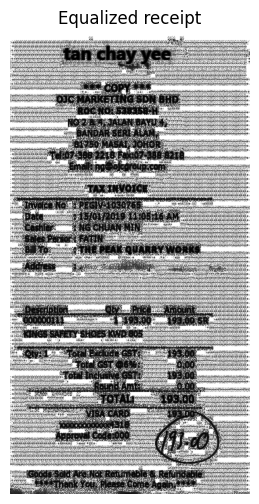

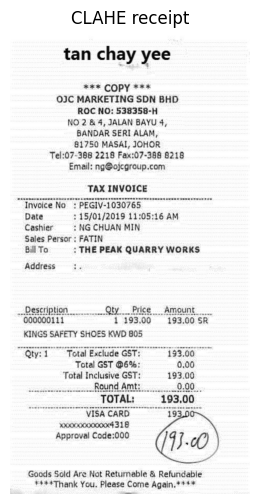

In [7]:
# Histogram equalization
rec_eq = cv2.equalizeHist(rec_gray_resized)
show_image("Equalized receipt", rec_eq, cmap='gray')

# OR CLAHE
clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
rec_clahe = clahe.apply(rec_gray_resized)
show_image("CLAHE receipt", rec_clahe, cmap='gray')

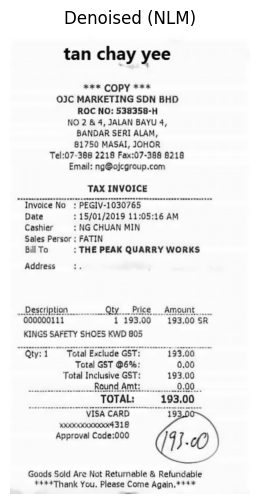

In [8]:
rec_denoised = cv2.fastNlMeansDenoising(rec_clahe, h=10)
show_image("Denoised (NLM)", rec_denoised, cmap='gray')

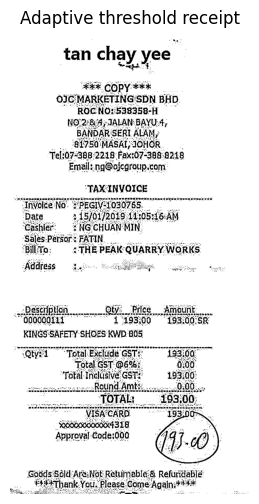

In [9]:
rec_adaptive = cv2.adaptiveThreshold(
    rec_denoised, 255,
    cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
    cv2.THRESH_BINARY,
    blockSize=11,
    C=2
)
show_image("Adaptive threshold receipt", rec_adaptive, cmap='gray')

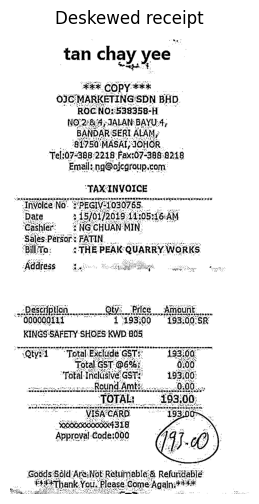

In [11]:
import numpy as np

def get_skew_angle(img):
    # Find edges
    edges = cv2.Canny(img, 50, 150, apertureSize=3)
    # Find lines using Hough transform
    lines = cv2.HoughLinesP(edges, 1, np.pi/180, 
                             threshold=100, 
                             minLineLength=100, 
                             maxLineGap=10)
    if lines is None:
        return 0.0
    angles = []
    for line in lines:
        x1, y1, x2, y2 = line[0]
        angle = np.degrees(np.arctan2(y2 - y1, x2 - x1))
        angles.append(angle)
    return np.median(angles)

def deskew(img):
    angle = get_skew_angle(img)
    if abs(angle) < 1.0:  # skip if almost straight
        return img
    h, w = img.shape
    center = (w // 2, h // 2)
    M = cv2.getRotationMatrix2D(center, angle, 1.0)
    rotated = cv2.warpAffine(img, M, (w, h),
                              flags=cv2.INTER_CUBIC,
                              borderMode=cv2.BORDER_REPLICATE)
    return rotated

rec_deskewed = deskew(rec_adaptive)
show_image("Deskewed receipt", rec_deskewed, cmap='gray')

In [12]:
def preprocess_receipt(img_path, target_width=800):
    # 1. Load
    img = cv2.imread(img_path)
    
    # 2. Grayscale
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    
    # 3. Resize to fixed width
    h, w = gray.shape
    scale = target_width / w
    gray = cv2.resize(gray, (target_width, int(h * scale)))
    
    # 4. CLAHE contrast enhancement
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    enhanced = clahe.apply(gray)
    
    # 5. Denoise
    denoised = cv2.GaussianBlur(enhanced, (3, 3), 0)
    
    # 6. Adaptive threshold
    thresh = cv2.adaptiveThreshold(
        denoised, 255,
        cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
        cv2.THRESH_BINARY,
        blockSize=11, C=2
    )
    
    # 7. Deskew
    final = deskew(thresh)
    
    return final

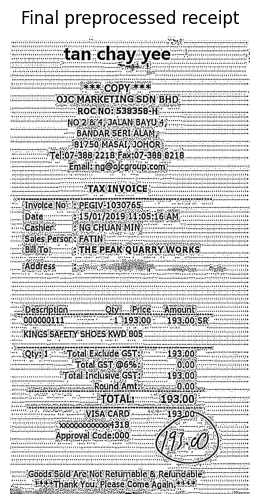

In [13]:
preprocessed = preprocess_receipt(rec_paths[0])
show_image("Final preprocessed receipt", preprocessed, cmap='gray')

In [14]:
import os

output_path = os.path.join(BASE_DIR, 'outputs', 'sample_preprocessed.png')
cv2.imwrite(output_path, preprocessed)
print("Saved to:", output_path)

Saved to: d:\HND NIBM\img processing & computer vision project\kyc-robustness\outputs\sample_preprocessed.png


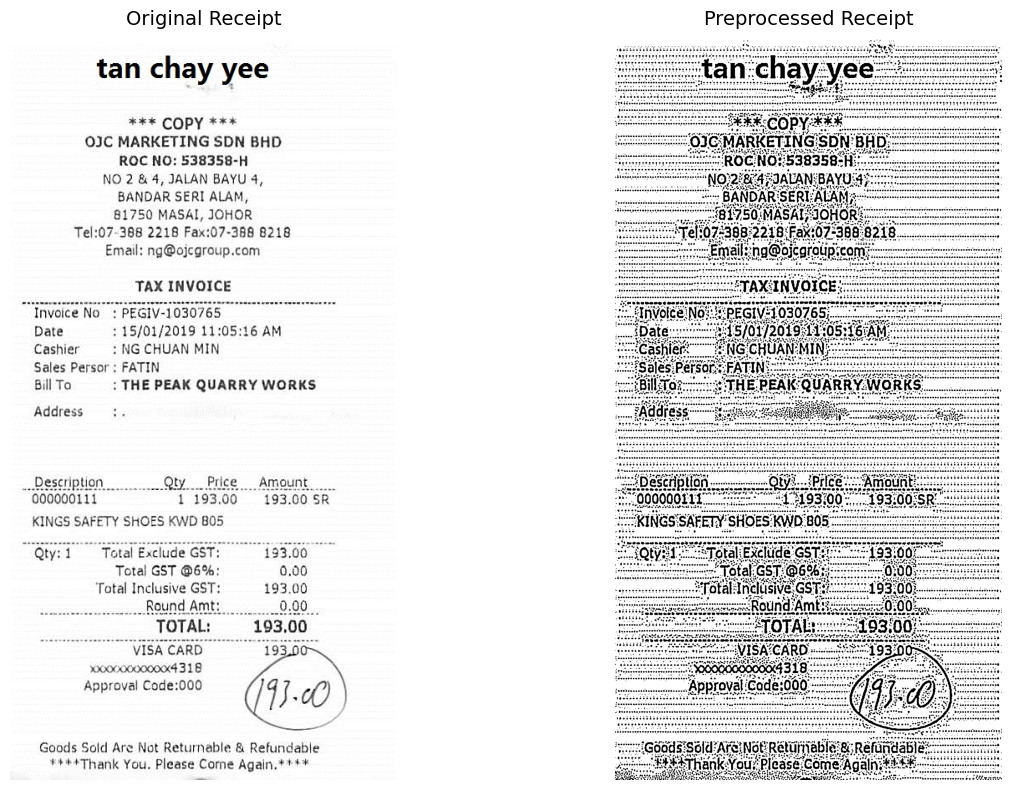

Comparison saved!


In [15]:
original = cv2.cvtColor(cv2.imread(rec_paths[0]), cv2.COLOR_BGR2RGB)

fig, axes = plt.subplots(1, 2, figsize=(14, 8))
axes[0].imshow(original)
axes[0].set_title("Original Receipt", fontsize=14)
axes[0].axis('off')

axes[1].imshow(preprocessed, cmap='gray')
axes[1].set_title("Preprocessed Receipt", fontsize=14)
axes[1].axis('off')

plt.tight_layout()
plt.savefig(os.path.join(BASE_DIR, 'outputs', 'before_after.png'), dpi=150)
plt.show()
print("Comparison saved!")